# Vježbe 10 — CNN: Konvolucijske neuralne mreže za klasifikaciju slika
**Predmet:** Rudarenje podataka — I. godina — II ciklus — Softversko inženjerstvo  
**Asistent:** ass. mr. Narcisa Hadžajlić  
**Datum:** 27.4.2026.

---

## Do sada rađeno:
- **Vježbe 8:** MLP — forward pass, backpropagation, loss kriva
- **Vježbe 9:** Aktivacijske funkcije (ReLU, Sigmoid, Softmax), overfitting, Dropout, Batch Normalization

## Danas:

MLP kojeg smo radili uzima **niz brojeva** kao input. Slika nije niz nego **mreža piksela s prostornim odnosima**. Piksele raspoređene u prostoru MLP ne zna iskoristiti.

**CNN (Convolutional Neural Network)** je tip mreže dizajniran specifično za prostorne podatke kao što su slike, ali i zvuk, video, pa čak i vremenski niz. Ključna razlika: umjesto da svaki neuron gleda sve piksele, CNN uči **lokalne obrasce** — ivice, teksture, oblike — i gradi razumijevanje od lokalnog ka globalnom. 

### Plan rada:
1. Intuitivno razumijevanje koncepata: šta je konvolucija, filter, feature map, pooling
2. Zašto CNN, a ne MLP za slike?
3. Implementacija CNN na MNIST datasetu rukom pisanih cifara
4. Vizualizacija: šta CNN "vidi" unutra?
5. Usporedba CNN vs. MLP na istom problemu
6. Zadatak — 3 boda

---
## 1. Intuicija — kako CNN radi

### Problem s MLP-om za slike

MNIST slika je 28×28 piksela = **784 broja**. MLP ih sve "sravni" u jedan vektor i svaki neuron gleda svih 784 piksela odjednom. Za MNIST bazu podataka to još uvijek radi. Međutim, za stvarnu fotografiju 224×224×3 (RGB) to je **150.528 inputa**, i broj parametara naglo raste i eksplodira! Još gore: MLP nema pojam da su pikseli prostorno povezani i za tu MLP mrežu je piksel na recimo poziciji (14,14) isti kao piksel na (0,0), bez konteksta okolnih piksela.

### Rješenje: Konvolucija

Zamislite da gledate sliku kroz mali prozor od npr. 3×3 piksela. Pomičete prozor po cijeloj slici i na svakoj poziciji radite istu operaciju: množite piksele s naučenim težinama i saberete. To je **konvolucija**.

Taj mali prozor zove se **filter (kernel)**. Mreža uči koji filteri su korisni: neki detektuju horizontalne ivice, neki vertikalne, neki uglove, neki teksture.

```
Filter koji detektuje vertikalnu ivicu:
[-1,  0,  1]
[-1,  0,  1]
[-1,  0,  1]
```

Rezultat primjene filtera na cijelu sliku zove se **feature map** i predstavlja novu sliku koja pokazuje gdje je taj obrazac prisutan.

### Pooling

Nakon konvolucije, **MaxPooling** smanjuje feature map uzimajući maksimalnu vrijednost iz svakog malog regiona (npr. 2×2). Efekt: smanjena dimenzionalnost, zadržana najvažnija informacija, manja osjetljivost na tačnu poziciju obrasca.

### Arhitektura CNN-a
```
Ulazna slika
    ↓
[Conv2D → ReLU] × N     ← uči lokalne obrasce
    ↓
[MaxPooling2D]           ← smanjuje dimenzije
    ↓
Flatten                  ← pretvara 2D u 1D
    ↓
[Dense → ReLU]           ← klasifikacija na osnovu naučenih featuri
    ↓
[Dense → Softmax]        ← output: vjerovatnoće po klasama
```

> **Ključna razlika od MLP-a:** Conv layeri **nemaju node-ove koji gledaju cijelu sliku** nego imaju filtere koji gledaju mali lokalni region i pomiču se po slici. Parametri filtera su **dijeljeni** po cijeloj slici te isti filter traži isti obrazac svugdje.

---
## 2. Implementacija

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

from sklearn.metrics import classification_report, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print("Sve uvezeno!")

TensorFlow: 2.21.0
Sve uvezeno!


### 2.1 Dataset — MNIST

**MNIST** je "Hello World" dataset za computer vision. Sadrži 70.000 slika rukom pisanih cifara (0-9), svaka 28×28 piksela u nijansama sive. Keras ga ima ugrađenog te nema potrebe za Kaggleom.

In [2]:
# Učitavanje — automatski se skida ako nije lokalno (~11MB)
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f"Train slike: {X_train_raw.shape}  → {X_train_raw.shape[0]} slika, svaka {X_train_raw.shape[1]}×{X_train_raw.shape[2]} piksela")
print(f"Test slike:  {X_test_raw.shape}")
print(f"Vrijednosti piksela: min={X_train_raw.min()}, max={X_train_raw.max()}")
print(f"Klase (cifre): {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train slike: (60000, 28, 28)  → 60000 slika, svaka 28×28 piksela
Test slike:  (10000, 28, 28)
Vrijednosti piksela: min=0, max=255
Klase (cifre): [0 1 2 3 4 5 6 7 8 9]


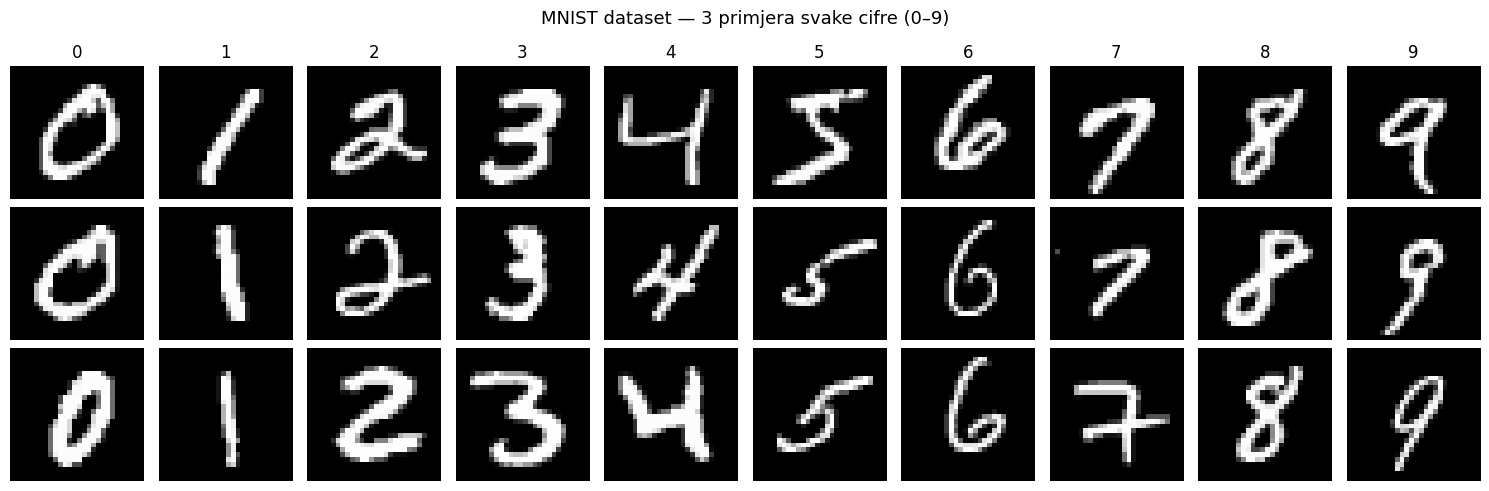

In [3]:
# Vizualizacija — pogledajmo šta imamo
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for cifra in range(10):
    # Uzmi 3 primjera svake cifre
    indeksi = np.where(y_train == cifra)[0][:3]
    for red, idx in enumerate(indeksi):
        axes[red, cifra].imshow(X_train_raw[idx], cmap='gray')
        axes[red, cifra].axis('off')
        if red == 0:
            axes[red, cifra].set_title(str(cifra), fontsize=12)

plt.suptitle('MNIST dataset — 3 primjera svake cifre (0–9)', fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Preprocessing slika

Dvije obavezne operacije za CNN:

1. **Normalizacija piksela** — vrijednosti su 0-255, dijelimo s 255 da dobijemo 0.0 - 1.0. Isti princip kao StandardScaler, ali za slike.
2. **Dodavanje channel dimenzije** — MNIST je grayscale (1 kanal). Conv2D u Kerasu očekuje oblik `(visina, širina, kanali)`. RGB slika bi imala 3 kanala za R, G i B, naša ima 1.

In [4]:
# Normalizacija: 0-255 → 0.0-1.0
X_train_cnn = X_train_raw.astype('float32') / 255.0
X_test_cnn  = X_test_raw.astype('float32') / 255.0

# Dodaj channel dimenziju: (60000, 28, 28) → (60000, 28, 28, 1)
X_train_cnn = X_train_cnn[..., np.newaxis]  # ... znači "sve prethodne dimenzije"
X_test_cnn  = X_test_cnn[..., np.newaxis]

print(f"Train shape: {X_train_cnn.shape}  ← (uzorci, visina, širina, kanali)")
print(f"Test shape:  {X_test_cnn.shape}")
print(f"Vrijednosti piksela sada: min={X_train_cnn.min():.1f}, max={X_train_cnn.max():.1f}")

# Za MLP nam treba flatten verzija (za kasniju usporedbu)
X_train_mlp = X_train_raw.astype('float32').reshape(60000, -1) / 255.0  # (60000, 784)
X_test_mlp  = X_test_raw.astype('float32').reshape(10000, -1)  / 255.0
print(f"\nMLP verzija (flatten): {X_train_mlp.shape}  ← gubi se prostorna struktura!")

Train shape: (60000, 28, 28, 1)  ← (uzorci, visina, širina, kanali)
Test shape:  (10000, 28, 28, 1)
Vrijednosti piksela sada: min=0.0, max=1.0

MLP verzija (flatten): (60000, 784)  ← gubi se prostorna struktura!


### 2.3 Vizualizacija konvolucije: šta filter radi?

Prije nego gradimo mrežu, pogledajmo ručno šta konvolucija radi na slici.

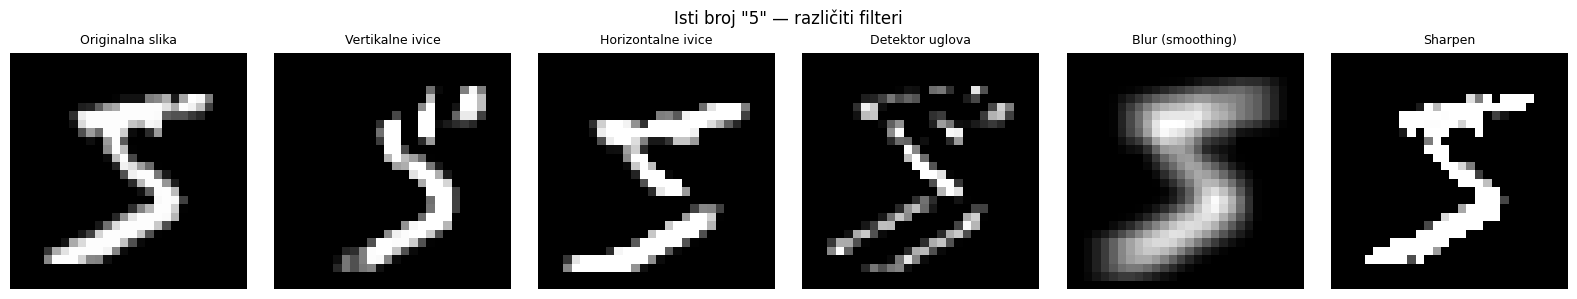

CNN uči stotine ovakvih filtera automatski — mi samo definišemo koliko ih hoćemo.


In [5]:
from scipy.ndimage import convolve

# Uzmimo jednu sliku
slika = X_train_raw[0].astype('float32')
cifra = y_train[0]

# Ručno definirani filteri (ovo CNN uči automatski)
filteri = {
    'Originalna slika':      None,
    'Vertikalne ivice':      np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype='float32'),
    'Horizontalne ivice':    np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype='float32'),
    'Detektor uglova':       np.array([[1,0,-1],[0,0,0],[-1,0,1]], dtype='float32'),
    'Blur (smoothing)':      np.ones((5,5), dtype='float32') / 25,
    'Sharpen':               np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype='float32'),
}

fig, axes = plt.subplots(1, len(filteri), figsize=(16, 3))

for ax, (naziv, filter_kernel) in zip(axes, filteri.items()):
    if filter_kernel is None:
        rezultat = slika
    else:
        rezultat = convolve(slika, filter_kernel)
        rezultat = np.clip(rezultat, 0, 255)  # odsijeci vrijednosti van opsega

    ax.imshow(rezultat, cmap='gray')
    ax.set_title(naziv, fontsize=9)
    ax.axis('off')

plt.suptitle(f'Isti broj "{cifra}" — različiti filteri', fontsize=12)
plt.tight_layout()
plt.show()

print("CNN uči stotine ovakvih filtera automatski — mi samo definišemo koliko ih hoćemo.")

### 2.4 Gradimo CNN

In [6]:
def napravi_cnn():
    model = keras.Sequential([
        # --- KONVOLUCIJSKI DIO --- uči prostorne obrasce
        layers.Input(shape=(28, 28, 1)),

        # Blok 1: 32 filtera, svaki 3×3
        layers.Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
        # padding='same' → output iste veličine kao input (dodaje nule na rubove)
        layers.MaxPooling2D(pool_size=(2,2)),
        # MaxPooling: 28×28 → 14×14, zadržava najjače aktivacije

        # Blok 2: 64 filtera — dublje = složeniji obrasci
        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),
        # 14×14 → 7×7

        # Blok 3: 64 filtera — bez poolinga da ne izgubimo previše
        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),

        # --- KLASIFIKACIJSKI DIO --- standardni MLP na naučenim featurima
        layers.Flatten(),
        # 7×7×64 = 3136 vrijednosti → jedan vektor

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
        # 10 izlaza — jedna vjerovatnoća po cifri (0-9)
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn = napravi_cnn()
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,570 (1.75 MB)

 Trainable params: 458,570 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Vizualizacija arhitekture — broj parametara po layeru
print("\nBroj parametara po layeru:")
print("-" * 50)
ukupno = 0
for layer in cnn.layers:
    params = layer.count_params()
    if params > 0:
        print(f"{layer.name:30s}  {params:>8,} parametara")
        ukupno += params
print("-" * 50)
print(f"{'UKUPNO':30s}  {ukupno:>8,} parametara")

print("\nZa usporedbu:")
print("MLP s jednim hidden layerom (784→512→10): ~401,930 parametara")
print("Naš CNN:                                  ~mnogo manje po conv layerima!")
print("\nZašto? Conv layer dijeli težine filtera po cijeloj slici.")
print("Conv2D(32, 3×3) ima samo 3×3×1×32 + 32 = 320 parametara — bez obzira na veličinu slike!")


Broj parametara po layeru:
--------------------------------------------------
conv2d                               320 parametara
conv2d_1                          18,496 parametara
conv2d_2                          36,928 parametara
dense                            401,536 parametara
dense_1                            1,290 parametara
--------------------------------------------------
UKUPNO                           458,570 parametara

Za usporedbu:
MLP s jednim hidden layerom (784→512→10): ~401,930 parametara
Naš CNN:                                  ~mnogo manje po conv layerima!

Zašto? Conv layer dijeli težine filtera po cijeloj slici.
Conv2D(32, 3×3) ima samo 3×3×1×32 + 32 = 320 parametara — bez obzira na veličinu slike!


### 2.5 Treniranje CNN-a

In [8]:
# EarlyStopping — zaustavi trening ako val_loss ne napreduje 5 epoha
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,           # čekaj 5 epoha bez poboljšanja pa stani
    restore_best_weights=True  # vrati težine iz najboljeg momenta
)

print("Treniranje CNN-a... (može potrajati 2-5 minuta)")

historija_cnn = cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTrening završen nakon {len(historija_cnn.history['loss'])} epoha.")

Treniranje CNN-a... (može potrajati 2-5 minuta)
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9421 - loss: 0.1891 - val_accuracy: 0.9840 - val_loss: 0.0542
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9819 - loss: 0.0582 - val_accuracy: 0.9880 - val_loss: 0.0397
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9876 - loss: 0.0412 - val_accuracy: 0.9913 - val_loss: 0.0333
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9867 - val_loss: 0.0445
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9916 - loss: 0.0259 - val_accuracy: 0.9915 - val_loss: 0.0320
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9934 - loss: 0.0207 - val_accuracy: 0.9900 - val_loss: 0.0353
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9943 - loss: 0.0180 - val_accuracy: 0.9937 - val_loss: 0.0303
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 16

In [9]:
# Evaluacija
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn, verbose=0), axis=1)
f1_cnn     = f1_score(y_test, y_pred_cnn, average='weighted')

print(f"CNN — F1 Score (test): {f1_cnn:.4f}")
print(f"CNN — Accuracy (test): {np.mean(y_pred_cnn == y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn))

CNN — F1 Score (test): 0.9925
CNN — Accuracy (test): 0.9925

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



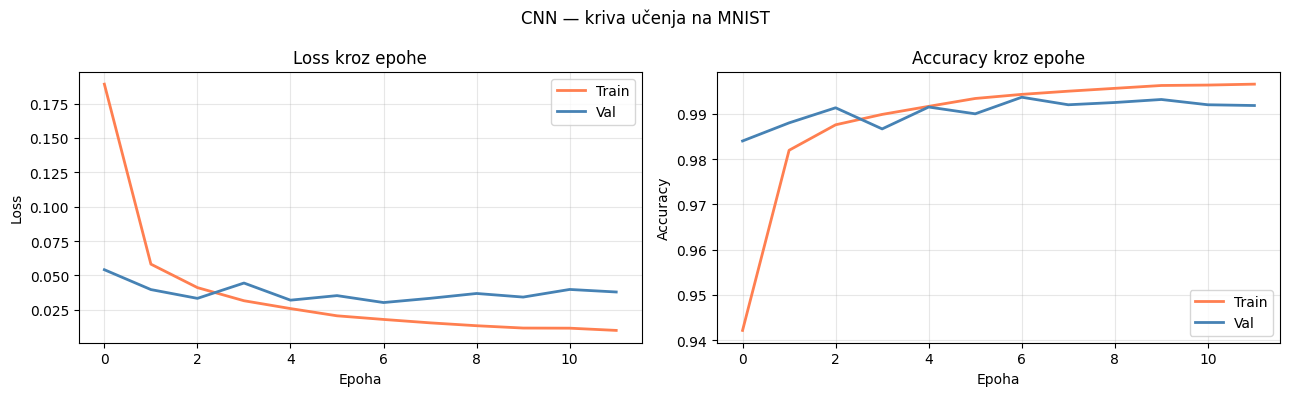

In [10]:
# Kriva učenja
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(historija_cnn.history['loss'],     label='Train', color='coral',     linewidth=2)
ax1.plot(historija_cnn.history['val_loss'], label='Val',   color='steelblue', linewidth=2)
ax1.set_title('Loss kroz epohe')
ax1.set_xlabel('Epoha')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historija_cnn.history['accuracy'],     label='Train', color='coral',     linewidth=2)
ax2.plot(historija_cnn.history['val_accuracy'], label='Val',   color='steelblue', linewidth=2)
ax2.set_title('Accuracy kroz epohe')
ax2.set_xlabel('Epoha')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN — kriva učenja na MNIST', fontsize=12)
plt.tight_layout()
plt.show()

### 2.6 Vizualizacija: šta CNN "vidi" unutra?

Ovo je najintuitivniji dio: Izvući ćemo feature maps iz prvog Conv layera i pogledati šta svaki filter aktivira.

Slika cifre: 2
Feature maps oblik: (1, 28, 28, 32)  ← (1 slika, 28×28, 32 filtera)


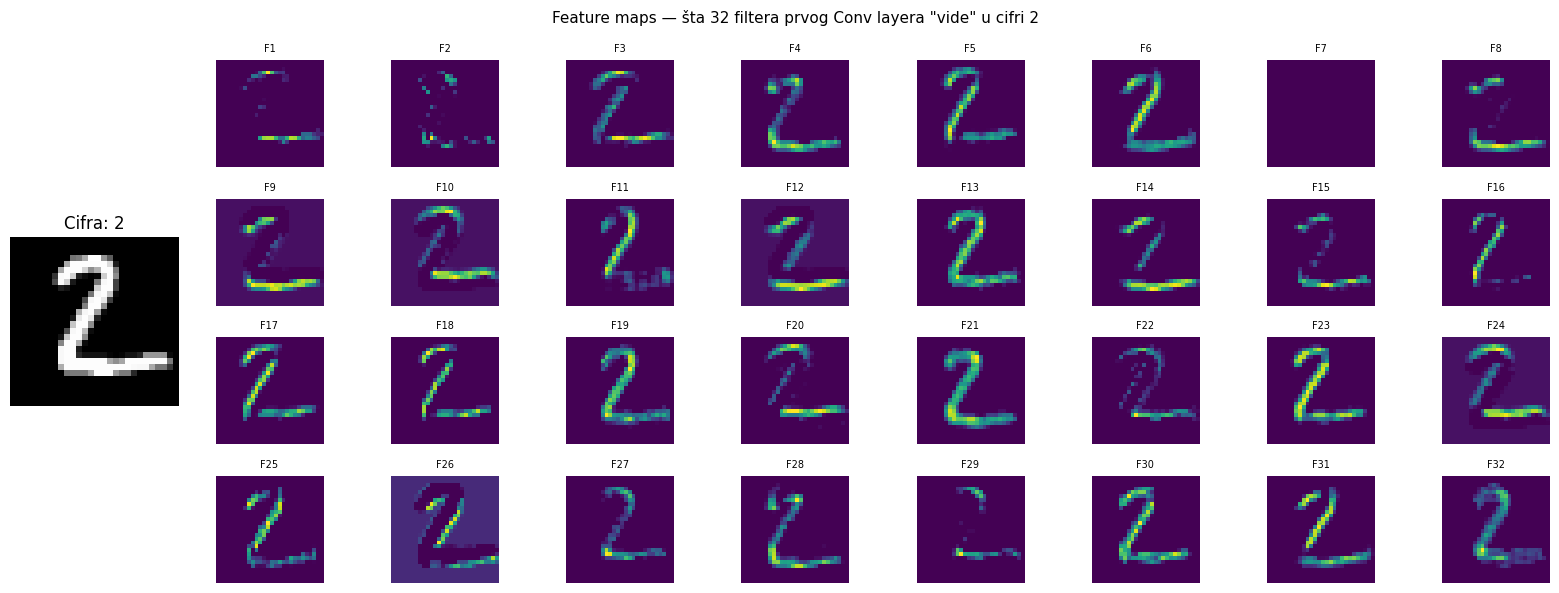

Svaki panel = jedan filter. Svjetlije = jača aktivacija = filter je detektovao taj obrazac.


In [13]:
# Model koji vraća output prvog Conv layera
# Fix za novije Keras verzije — koristimo funkcionalni API direktno

# Uzimamo drugi layer jer je layers[0] InputLayer u novijim verzijama
# Pronađemo prvi Conv2D layer automatski
prvi_conv = next(l for l in cnn.layers if isinstance(l, layers.Conv2D))

layer_output_model = keras.Model(
    inputs=cnn.inputs,          # .inputs umjesto .input (lista, ne tensor)
    outputs=prvi_conv.output
)

# Uzmimo jednu sliku
idx         = 1
test_slika  = X_test_cnn[idx:idx+1]
prava_klasa = y_test[idx]

# Feature maps
feature_maps = layer_output_model.predict(test_slika, verbose=0)
print(f"Slika cifre: {prava_klasa}")
print(f"Feature maps oblik: {feature_maps.shape}  ← (1 slika, 28×28, 32 filtera)")

# Prikaz originalnog i feature mapa
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(4, 9, figure=fig)

ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(X_test_raw[idx], cmap='gray')
ax_orig.set_title(f'Cifra: {prava_klasa}', fontsize=12)
ax_orig.axis('off')

for i in range(32):
    red = i // 8
    kol = (i % 8) + 1
    ax  = fig.add_subplot(gs[red, kol])
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle(f'Feature maps — šta 32 filtera prvog Conv layera "vide" u cifri {prava_klasa}', fontsize=11)
plt.tight_layout()
plt.show()

print("Svaki panel = jedan filter. Svjetlije = jača aktivacija = filter je detektovao taj obrazac.")

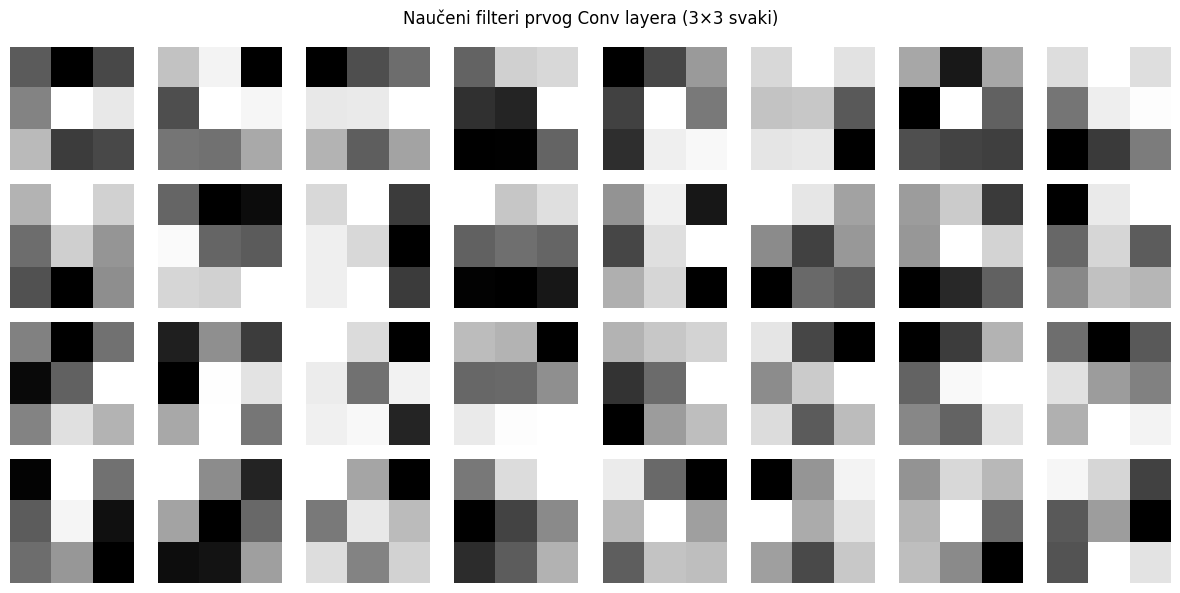

Ovi 3×3 obrasci su ono što CNN traži u svakom dijelu slike.
Neki liče na ivice, neki na uglove i mreža ih je naučila sama!


In [15]:
# Vizualizacija naučenih filtera (težina) iz prvog Conv layera
filteri_nauceni = cnn.layers[0].get_weights()[0]  # oblik: (3, 3, 1, 32)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    f = filteri_nauceni[:, :, 0, i]
    # Normalizuj za prikaz
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, cmap='gray')
    ax.axis('off')

plt.suptitle('Naučeni filteri prvog Conv layera (3×3 svaki)', fontsize=12)
plt.tight_layout()
plt.show()

print("Ovi 3×3 obrasci su ono što CNN traži u svakom dijelu slike.")
print("Neki liče na ivice, neki na uglove i mreža ih je naučila sama!")

### 2.7 Konfuzna matrica (Confusion Matrix): gdje CNN griješi?

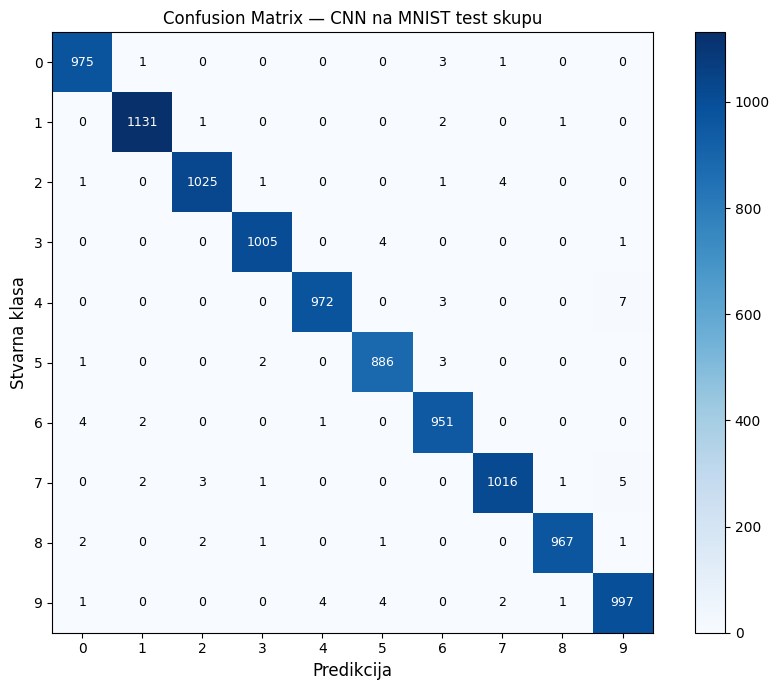


Najčešće greške (van dijagonale):
  Stvarna: 4, Predviđena: 9  →  7 puta
  Stvarna: 7, Predviđena: 9  →  5 puta
  Stvarna: 2, Predviđena: 7  →  4 puta
  Stvarna: 3, Predviđena: 5  →  4 puta
  Stvarna: 6, Predviđena: 0  →  4 puta


In [16]:
cm = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_xlabel('Predikcija', fontsize=12)
ax.set_ylabel('Stvarna klasa', fontsize=12)
ax.set_title('Confusion Matrix — CNN na MNIST test skupu', fontsize=12)

for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=9,
                color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Najčešće greške
print("\nNajčešće greške (van dijagonale):")
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
for _ in range(5):
    i, j = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"  Stvarna: {i}, Predviđena: {j}  →  {cm_copy[i,j]} puta")
    cm_copy[i,j] = 0

Ukupno grešaka: 75 od 10000 (0.75%)


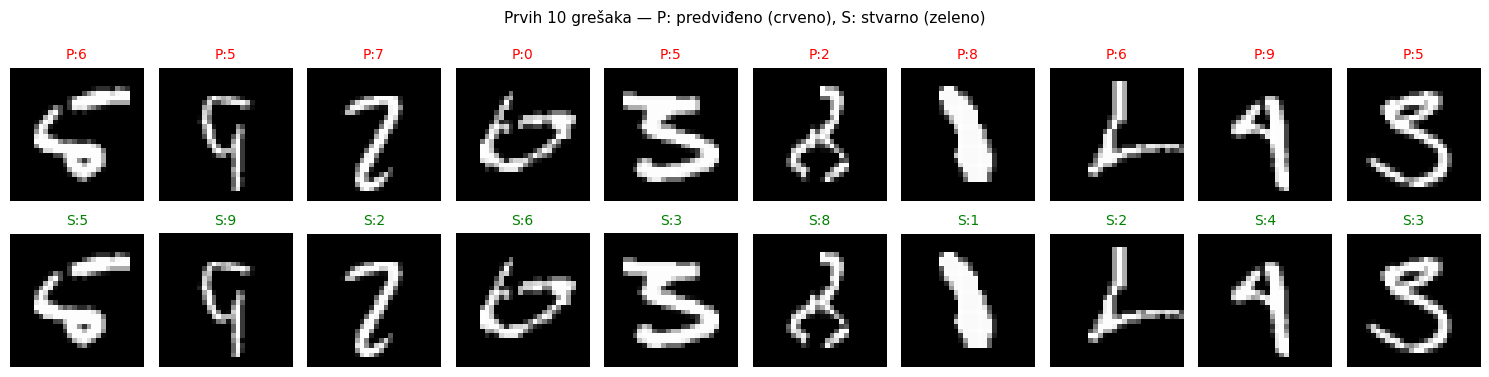


Primijetite: čak i slike na kojima je CNN pogriješio su često ambivalentne za ljudsko oko.


In [17]:
# Primjeri gdje je CNN pogriješio
pogresne_maske = y_pred_cnn != y_test
pogresni_idx   = np.where(pogresne_maske)[0]

print(f"Ukupno grešaka: {len(pogresni_idx)} od {len(y_test)} ({len(pogresni_idx)/len(y_test)*100:.2f}%)")

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, idx in enumerate(pogresni_idx[:10]):
    axes[0, i].imshow(X_test_raw[idx], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'P:{y_pred_cnn[idx]}', color='red', fontsize=10)

    axes[1, i].imshow(X_test_raw[idx], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'S:{y_test[idx]}', color='green', fontsize=10)

plt.suptitle('Prvih 10 grešaka — P: predviđeno (crveno), S: stvarno (zeleno)', fontsize=11)
plt.tight_layout()
plt.show()

print("\nPrimijetite: čak i slike na kojima je CNN pogriješio su često ambivalentne za ljudsko oko.")

### 2.8 CNN vs. MLP: usporedba na istom problemu

In [18]:
# MLP za klasifikaciju cifara
print("Treniranje MLP-a za usporedbu...")

mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
mlp.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

historija_mlp = mlp.fit(
    X_train_mlp, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

y_pred_mlp = np.argmax(mlp.predict(X_test_mlp, verbose=0), axis=1)
f1_mlp     = f1_score(y_test, y_pred_mlp, average='weighted')

print(f"\nRezultati na MNIST test skupu:")
print("-" * 45)
print(f"{'Model':10s}  {'F1 Score':>10s}  {'Accuracy':>10s}  {'Parametri':>12s}")
print("-" * 45)
print(f"{'CNN':10s}  {f1_cnn:>10.4f}  {np.mean(y_pred_cnn==y_test):>10.4f}  {cnn.count_params():>12,}")
print(f"{'MLP':10s}  {f1_mlp:>10.4f}  {np.mean(y_pred_mlp==y_test):>10.4f}  {mlp.count_params():>12,}")

Treniranje MLP-a za usporedbu...

Rezultati na MNIST test skupu:
---------------------------------------------
Model         F1 Score    Accuracy     Parametri
---------------------------------------------
CNN             0.9925      0.9925       458,570
MLP             0.9782      0.9782       535,818


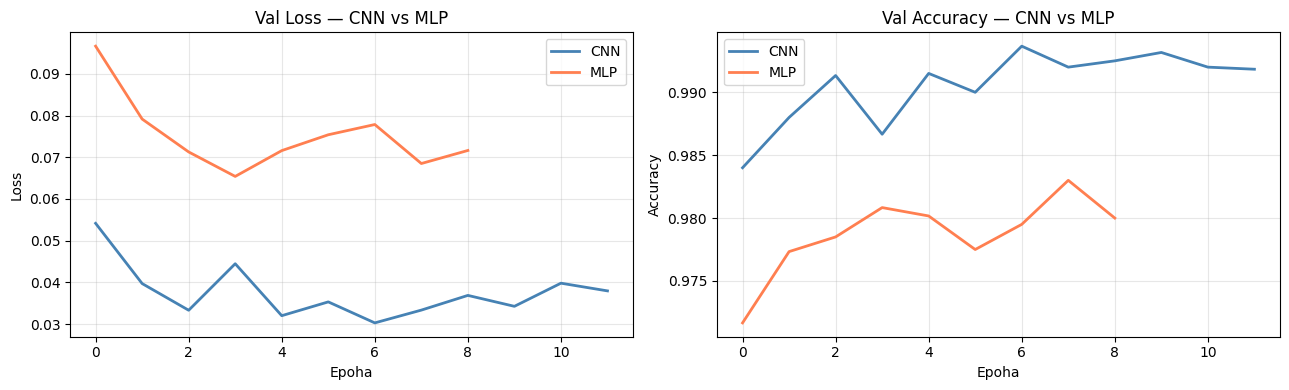


Zaključak: CNN postiže bolji rezultat s manje parametara jer koristi prostornu strukturu slike.
Na složenijim slikama (CIFAR-10, fotografije) razlika bi bila još dramatičnija.


In [19]:
# Vizualizacija usporedbe
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for hist, naziv, boja in [
    (historija_cnn, 'CNN', 'steelblue'),
    (historija_mlp, 'MLP', 'coral')
]:
    axes[0].plot(hist.history['val_loss'],     label=naziv, color=boja, linewidth=2)
    axes[1].plot(hist.history['val_accuracy'], label=naziv, color=boja, linewidth=2)

for ax, naslov, ylabel in zip(axes,
    ['Val Loss — CNN vs MLP', 'Val Accuracy — CNN vs MLP'],
    ['Loss', 'Accuracy']):
    ax.set_xlabel('Epoha')
    ax.set_ylabel(ylabel)
    ax.set_title(naslov)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nZaključak: CNN postiže bolji rezultat s manje parametara jer koristi prostornu strukturu slike.")
print("Na složenijim slikama (CIFAR-10, fotografije) razlika bi bila još dramatičnija.")

---
## 3. Šta smo naučili danas

| Koncept | Šta znači |
|---|---|
| **Conv2D(N, (k,k))** | N filtera veličine k×k, svaki uči lokalni obrazac |
| **padding='same'** | Output iste veličine kao input (dodaju se nule na rubove) |
| **MaxPooling2D** | Smanjuje prostorne dimenzije, zadržava najjače aktivacije |
| **Flatten** | Pretvara 2D feature mapu u 1D vektor za Dense layere |
| **Feature map** | Rezultat primjene filtera na sliku — gdje je obrazac prisutan |
| **Channel** | Dimenzija boje (1 za grayscale, 3 za RGB) |
| **EarlyStopping** | Zaustavlja trening kada val_loss ne poboljšava N epoha |
| **restore_best_weights** | Vraća težine iz epohe s najboljim val_lossom |

---
## ZADATAK — 3 BODA

**Rok:** Predaja na Google Classroom do 23:59 utorak 28.04.2026.

### Šta trebate uraditi:

1. **Pronađite image classification dataset** na internetu:
   - Neki primjeri dataset-ova: `Intel Image Classification` (priroda/grad, 6 klasa), `Fruits 360`, `Rock Paper Scissors`, `Weather Image Recognition`
   - Dataset ne mora biti velik — 1.000-5.000 slika je sasvim dovoljno
   - Ako je dataset prevelik, uzmite podskup

2. **Implementirajte CNN** s barem 2 Conv2D layera i prikažite:
   - Preprocessing (normalizacija, reshape)
   - `model.summary()` — arhitektura i broj parametara
   - Kriva učenja (train vs. val)
   - F1 score i classification report

3. **Vizualizujte feature maps** prvog Conv layera za barem jednu sliku iz vašeg dataseta

4. **Napišite komentar** (markdown ćelija):
   - Koji dataset ste uzeli i zašto?
   - Koliko Conv layera ste koristili i zašto?
   - Šta vidite u feature mapama — prepoznajete li kakve obrasce?


### Bodovanje:
- **1 bod** — CNN radi, kriva učenja prikazana, F1 score izračunat
- **1 bod** — Vlastiti dataset, feature maps vizualizirane, `model.summary()` prikazan
- **1 bod** — Markdown komentar koji pokazuje razumijevanje

**Bonus izazov (+1 bod):** Pokušajte dodati još jedan Conv blok ili promijeniti broj filtera. Poboljšava li se F1? Usporedite s MLP-om na istom datasetu.